# WorldStrat LR / HR Viewer Notebook

For Super-Resolution tasks. Uses the improved visualization from previous scripts.

In [ ]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os

# ================== SINGLE LR VIEWER ==================
def view_lr_tiff(tiff_path):
    with rasterio.open(tiff_path) as src:
        print("=== LR Metadata ===")
        print(src.profile)
        data = src.read()
        print("\n=== LR Band Statistics ===")
        for i in range(src.count):
            band = data[i]
            print(f"Band {i+1}: min={band.min():.4f}, max={band.max():.4f}, mean={band.mean():.4f}")
        
        # Sentinel-2 typical RGB: B4, B3, B2 (0-based indices 3,2,1)
        red = data[3].astype(np.float32)
        green = data[2].astype(np.float32)
        blue = data[1].astype(np.float32)
        
        def stretch(band):
            p2, p98 = np.percentile(band, (2, 98))
            return np.clip((band - p2) / (p98 - p2 + 1e-6) * 255, 0, 255)
        
        rgb = np.dstack((stretch(red), stretch(green), stretch(blue))).astype(np.uint8)
        
        plt.figure(figsize=(10, 10))
        plt.imshow(rgb)
        plt.title(f"LR: {os.path.basename(tiff_path)}")
        plt.axis('off')
        plt.show()
        
        save_path = tiff_path.replace('.tiff', '_visualized.png')
        Image.fromarray(rgb).save(save_path)
        print(f"Saved: {save_path}")
        return rgb

=== LR Metadata ===
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': 0.0, 'width': 155, 'height': 161, 'count': 13, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.00011914021710150417, 0.0, 46.740639946043665,
       0.0, -8.845031589213483e-05, 39.81024551346196), 'blockxsize': 155, 'blockysize': 1, 'tiled': False, 'interleave': 'pixel'}

=== LR Band Statistics ===
Band 1: min=0.1105, max=0.1637, mean=0.1338
Band 2: min=0.0767, max=0.5916, mean=0.1188
Band 3: min=0.0624, max=0.6699, mean=0.1159
Band 4: min=0.0454, max=0.8409, mean=0.1205
Band 5: min=0.0649, max=0.3534, mean=0.1427
Band 6: min=0.0857, max=0.5095, mean=0.2032
Band 7: min=0.1045, max=0.4019, mean=0.2362
Band 8: min=0.0652, 

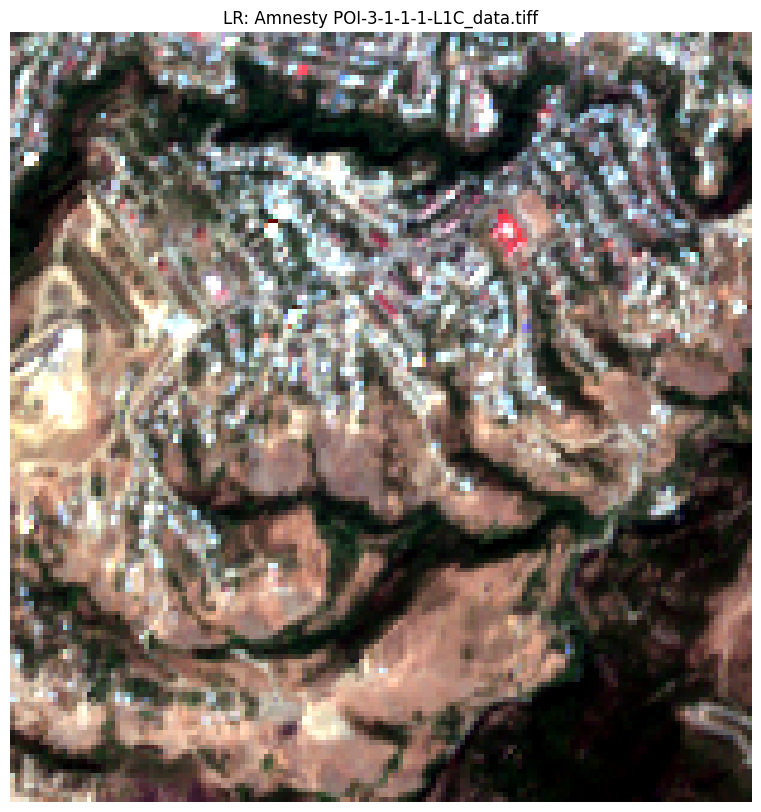

Saved: /home/hassan/Documents/Hassan/SR Enhancement Work/Datasets/WorldStrat/lr_dataset_l1c/lr_dataset/Amnesty POI-3-1-1/L1C/Amnesty POI-3-1-1-1-L1C_data_visualized.png


array([[[ 56,  49,  51],
        [ 37,  39,  44],
        [ 51,  55,  48],
        ...,
        [138, 109,  91],
        [129,  97,  97],
        [146, 116, 115]],

       [[ 71,  60,  62],
        [ 66,  84,  69],
        [ 90, 110,  93],
        ...,
        [ 80, 103,  80],
        [107,  80,  72],
        [126, 115, 104]],

       [[ 96,  76,  74],
        [ 80,  85,  77],
        [137, 143, 126],
        ...,
        [104, 132, 104],
        [103,  99,  91],
        [117, 120,  97]],

       ...,

       [[229, 202, 178],
        [127, 115, 107],
        [151, 138, 116],
        ...,
        [ 20,  25,  10],
        [ 27,  25,  16],
        [ 28,  28,  19]],

       [[229, 202, 178],
        [197, 171, 163],
        [184, 167, 137],
        ...,
        [ 20,  19,   9],
        [ 20,  27,  10],
        [ 17,  26,  14]],

       [[250, 227, 205],
        [248, 228, 211],
        [238, 222, 196],
        ...,
        [ 20,  16,   8],
        [ 22,  18,  12],
        [ 20,  14,  10]]

In [2]:
# Single LR
lr_path = '/home/hassan/Documents/Hassan/SR Enhancement Work/Datasets/WorldStrat/lr_dataset_l1c/lr_dataset/Amnesty POI-3-1-1/L1C/Amnesty POI-3-1-1-1-L1C_data.tiff'
view_lr_tiff(lr_path)

## Usage Examples

```python
# Single LR
lr_path = 'path/to/Amnesty POI-1-1-1-1-L2A_data.tiff'
view_lr_tiff(lr_path)

# Single HR
hr_path = 'path/to/Amnesty POI-2-3-2_ps.tiff'
view_hr_tiff(hr_path)

# Side by side
compare_lr_hr(lr_path, hr_path)

# Batch
batch_visualize_lr('/path/to/lr_dataset')
batch_visualize_hr('/path/to/hr_dataset')
```

In [ ]:
# ================== SINGLE HR VIEWER ==================
def view_hr_tiff(tiff_path):
    with rasterio.open(tiff_path) as src:
        print("=== HR Metadata ===")
        print(src.profile)
        data = src.read()
        print("\n=== HR Band Statistics ===")
        for i in range(src.count):
            band = data[i]
            print(f"Band {i+1}: min={band.min():.2f}, max={band.max():.2f}, mean={band.mean():.2f}")
        
        # SPOT ps.tiff correct ordering: Band1=Blue, Band2=Green, Band3=Red
        blue = data[0].astype(np.float32)
        green = data[1].astype(np.float32)
        red = data[2].astype(np.float32)
        
        def stretch(band):
            p2, p98 = np.percentile(band[band > 0], (2, 98)) if np.any(band > 0) else (0, 255)
            return np.clip((band - p2) / (p98 - p2 + 1e-6) * 255, 0, 255)
        
        rgb = np.dstack((stretch(red), stretch(green), stretch(blue))).astype(np.uint8)
        
        plt.figure(figsize=(10, 10))
        plt.imshow(rgb)
        plt.title(f"HR: {os.path.basename(tiff_path)}")
        plt.axis('off')
        plt.show()
        
        save_path = tiff_path.replace('.tiff', '_visualized.png')
        Image.fromarray(rgb).save(save_path)
        print(f"Saved: {save_path}")
        return rgb

/home/hassan/miniconda3/envs/mlbase/lib/python3.11/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


=== HR Metadata ===
{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': None, 'width': 1054, 'height': 1054, 'count': 4, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(1.0, 0.0, 0.0,
       0.0, 1.0, 0.0), 'blockxsize': 1054, 'blockysize': 1, 'tiled': False, 'interleave': 'pixel'}

=== HR Band Statistics ===
Band 1: min=0.00, max=12357.00, mean=765.39
Band 2: min=0.00, max=11573.00, mean=662.53
Band 3: min=0.00, max=11889.00, mean=491.93
Band 4: min=0.00, max=16848.00, mean=1555.74


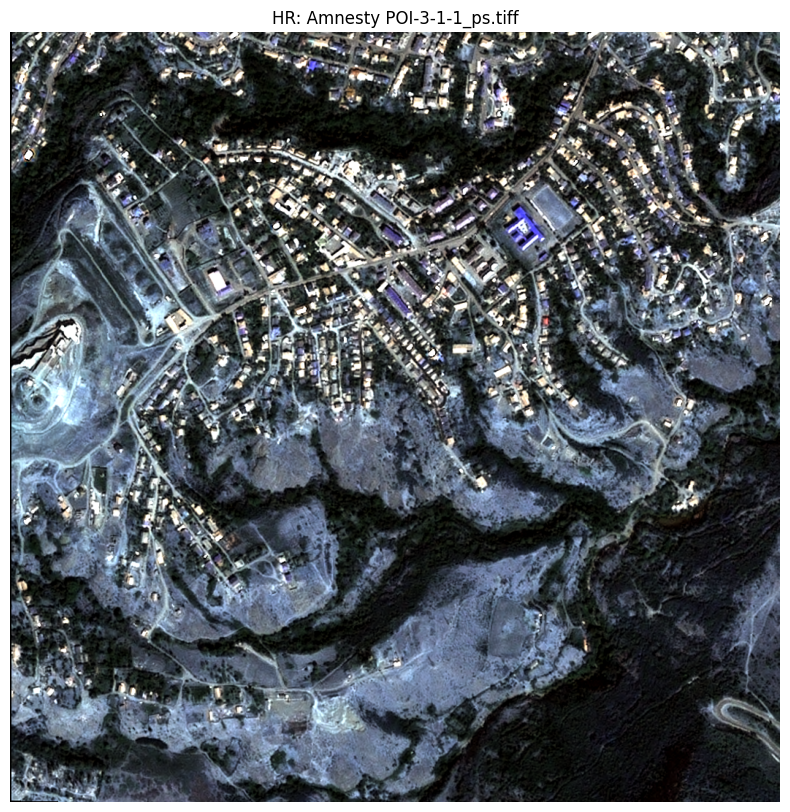

Saved: /home/hassan/Documents/Hassan/SR Enhancement Work/Datasets/WorldStrat/hr_dataset_p/Amnesty POI-3-1-1/Amnesty POI-3-1-1_ps_visualized.png


array([[[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [ 94, 106, 111],
        [101, 113, 119],
        [104, 116, 122]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [109, 122, 127],
        [105, 118, 123],
        [102, 115, 120]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [101, 114, 118],
        [ 99, 111, 116],
        [103, 116, 121]],

       ...,

       [[  0,   0,   0],
        [  0,   0,   0],
        [158, 180, 208],
        ...,
        [ 16,  21,  30],
        [ 15,  20,  30],
        [ 13,  17,  27]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [ 29,  35,  46],
        [ 28,  33,  45],
        [ 22,  27,  38]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [ 24,  30,  41],
        [ 27,  32,  44],
        [ 25,  30,  42]]

In [4]:
# Single HR
hr_path = '/home/hassan/Documents/Hassan/SR Enhancement Work/Datasets/WorldStrat/hr_dataset_p/Amnesty POI-3-1-1/Amnesty POI-3-1-1_ps.tiff'
view_hr_tiff(hr_path)

In [6]:
# ================== SIDE-BY-SIDE COMPARISON ==================
def compare_lr_hr(lr_path, hr_path):
    lr_rgb = view_lr_tiff(lr_path)  # This will also print stats and show image
    hr_rgb = view_hr_tiff(hr_path)
    
    fig, axs = plt.subplots(1, 2, figsize=(20, 10))
    axs[0].imshow(lr_rgb)
    axs[0].set_title('LR Image')
    axs[0].axis('off')
    axs[1].imshow(hr_rgb)
    axs[1].set_title('HR Image')
    axs[1].axis('off')
    plt.tight_layout()
    plt.show()

=== LR Metadata ===
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': 0.0, 'width': 155, 'height': 161, 'count': 13, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(0.00011914021710150417, 0.0, 46.740639946043665,
       0.0, -8.845031589213483e-05, 39.81024551346196), 'blockxsize': 155, 'blockysize': 1, 'tiled': False, 'interleave': 'pixel'}

=== LR Band Statistics ===
Band 1: min=0.1105, max=0.1637, mean=0.1338
Band 2: min=0.0767, max=0.5916, mean=0.1188
Band 3: min=0.0624, max=0.6699, mean=0.1159
Band 4: min=0.0454, max=0.8409, mean=0.1205
Band 5: min=0.0649, max=0.3534, mean=0.1427
Band 6: min=0.0857, max=0.5095, mean=0.2032
Band 7: min=0.1045, max=0.4019, mean=0.2362
Band 8: min=0.0652, 

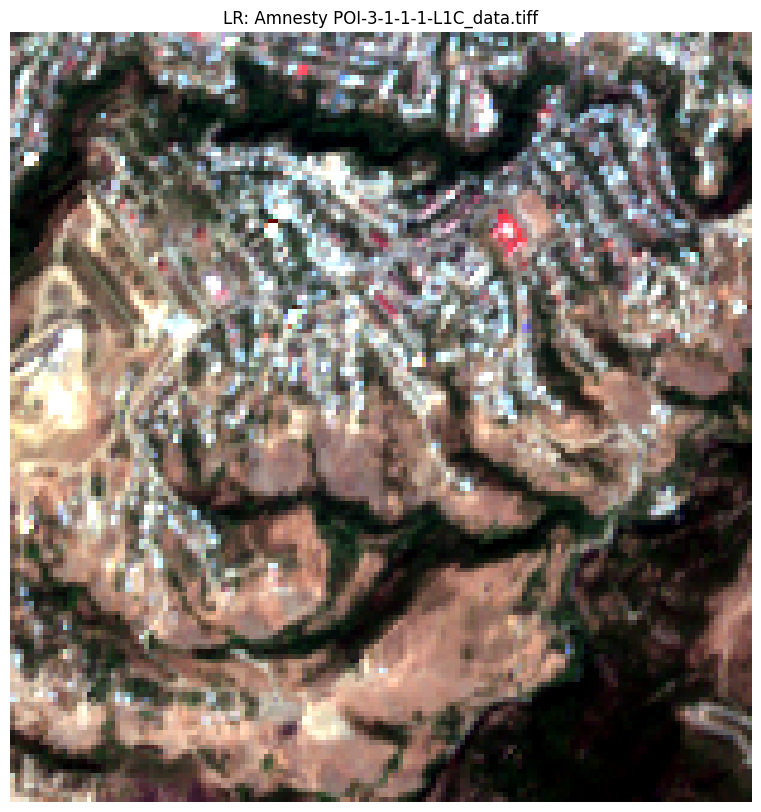

Saved: /home/hassan/Documents/Hassan/SR Enhancement Work/Datasets/WorldStrat/lr_dataset_l1c/lr_dataset/Amnesty POI-3-1-1/L1C/Amnesty POI-3-1-1-1-L1C_data_visualized.png
=== HR Metadata ===
{'driver': 'GTiff', 'dtype': 'uint16', 'nodata': None, 'width': 1054, 'height': 1054, 'count': 4, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'), 'transform': Affine(1.0, 0.0, 0.0,
       0.0, 1.0, 0.0), 'blockxsize': 1054, 'blockysize': 1, 'tiled': False, 'interleave': 'pixel'}

=== HR Band Statistics ===
Band 1: min=0.00, max=12357.00, mean=765.39
Band 2: min=0.00, max=11573.00, mean=662.53
Band 3: min=0.00, max=11889.00, mean=491.93
Band 4: min=0.00, max=16848.00, mean=1555.74


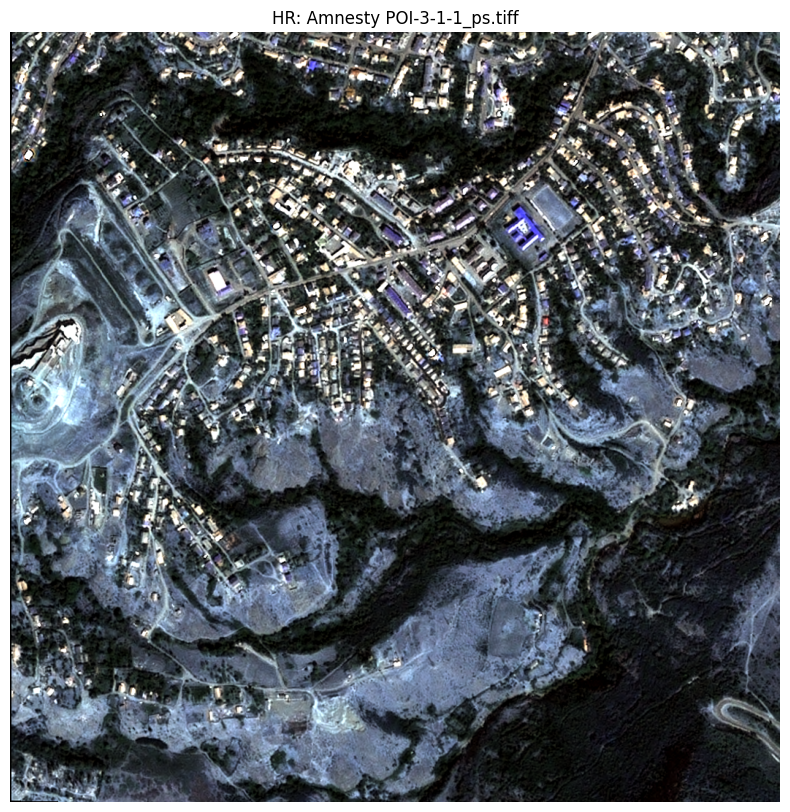

Saved: /home/hassan/Documents/Hassan/SR Enhancement Work/Datasets/WorldStrat/hr_dataset_p/Amnesty POI-3-1-1/Amnesty POI-3-1-1_ps_visualized.png


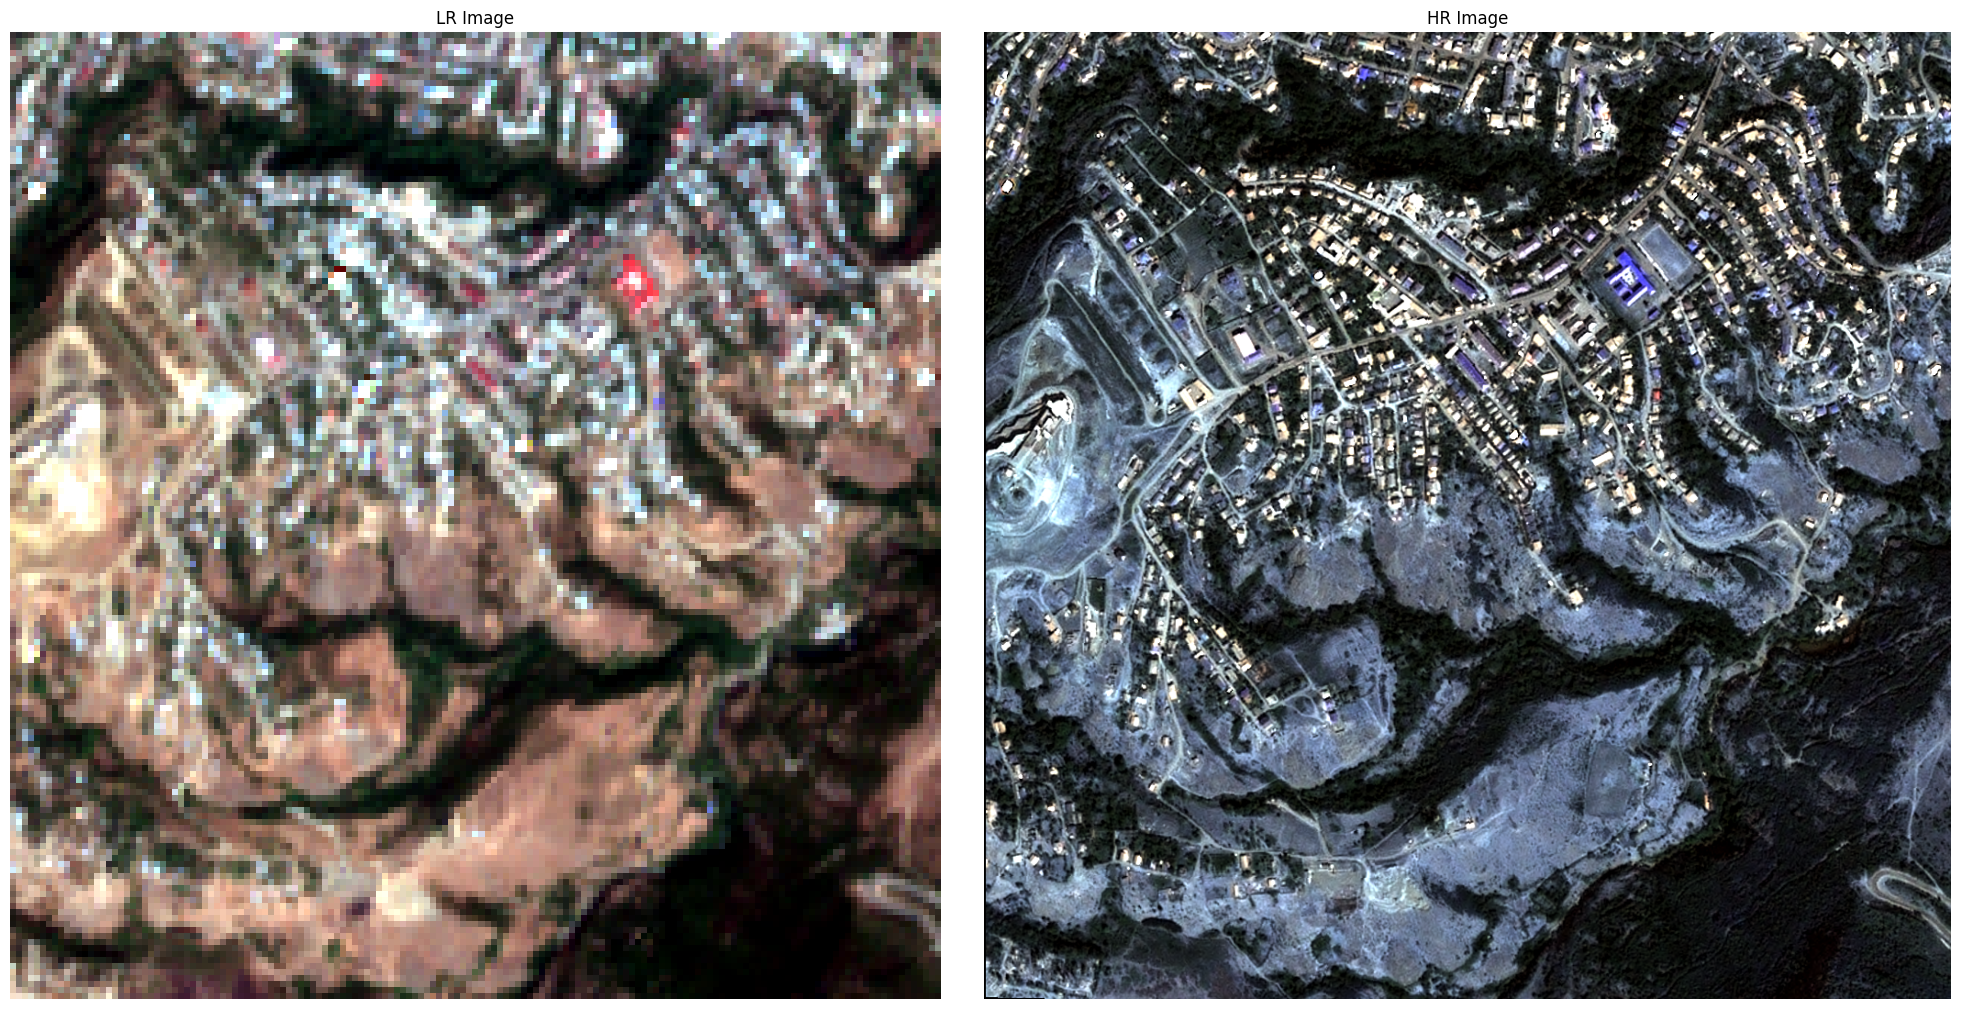

In [7]:
# Side by side
compare_lr_hr(lr_path, hr_path)

In [50]:
from tqdm import tqdm
# ================== BATCH PROCESS LR ==================
def save_optimise_lr_tiff(input_tiff_path, out_tiff_path):
    with rasterio.open(input_tiff_path) as src:
        data = src.read()
        # Sentinel-2 typical RGB: B4, B3, B2 (0-based indices 3,2,1)
        red = data[3].astype(np.float32)
        green = data[2].astype(np.float32)
        blue = data[1].astype(np.float32)
        
        def stretch(band):
            p2, p98 = np.percentile(band, (2, 98))
            return np.clip((band - p2) / (p98 - p2 + 1e-6) * 255, 0, 255)
    
        rgb = np.dstack((stretch(red), stretch(green), stretch(blue))).astype(np.uint8)
        save_path = out_tiff_path.replace('.tiff', '_visualized.png')
        # print(save_path)
        # return
        Image.fromarray(rgb).save(save_path)
        

def batch_visualize_lr(input_dir, output_base_dir='/home/hassan/Documents/Hassan/SR Enhancement Work/Datasets/WorldStrat/visualized_worldstrat/visualized_lr'):
    os.makedirs(output_base_dir, exist_ok=True)
    
    # Collect files first for clean tqdm progress
    lr_files = []
    for root, dirs, files in os.walk(input_dir):
        for file in files:
            if file.endswith(('-L2A_data.tiff', '.tiff')) and 'L2A_data' in file:
                lr_files.append((root, file))
    # print(f"lr_files = {lr_files}")
    for root, file in tqdm(lr_files, desc="Processing LR images", unit="image"):
        input_tiff_path = os.path.join(root, file)
        rel_path = os.path.relpath(root, input_dir)
        out_dir = os.path.join(output_base_dir, rel_path)
        os.makedirs(out_dir, exist_ok=True)
        out_tiff_path = os.path.join(out_dir, file)
        # print(out_tiff_path)
        # print(input_tiff_path)
        # view_lr_tiff will save the visualised tiff as PNG
        # break
        save_optimise_lr_tiff(input_tiff_path, out_tiff_path)
        # break

In [51]:
# Batch
batch_visualize_lr('/home/hassan/Documents/Hassan/SR Enhancement Work/Datasets/WorldStrat/lr_dataset_l2a/lr_dataset')

Processing LR images:  23%|██▎       | 14377/62848 [01:18<04:19, 186.88image/s]/tmp/ipykernel_30747/2560942878.py:13: RuntimeWarning: invalid value encountered in subtract
  return np.clip((band - p2) / (p98 - p2 + 1e-6) * 255, 0, 255)
/tmp/ipykernel_30747/2560942878.py:15: RuntimeWarning: invalid value encountered in cast
  rgb = np.dstack((stretch(red), stretch(green), stretch(blue))).astype(np.uint8)
Processing LR images:  37%|███▋      | 23518/62848 [02:10<03:39, 179.59image/s]


RasterioIOError: Read failed. See previous exception for details.

In [ ]:
# print(os.walk('/home/hassan/Documents/Hassan/SR Enhancement Work/Datasets/WorldStrat/lr_dataset_l2a/lr_dataset'))
input_dir = "/home/hassan/Documents/Hassan/SR Enhancement Work/Datasets/WorldStrat/lr_dataset_l2a/lr_dataset"
import os

for dirpath, dirnames, filenames in os.walk(input_dir):
    print(f"Path: {dirpath}")
    print(f"Subdirectories: {dirnames}")
    print(f"Files: {filenames}")
    print("-" * 20)

In [56]:
# ================== BATCH PROCESS HR ==================
def save_optimise_hr_tiff(input_tiff_path, out_tiff_path):
    with rasterio.open(input_tiff_path) as src:
        data = src.read()
        
        # SPOT ps.tiff correct ordering: Band1=Blue, Band2=Green, Band3=Red
        red = data[0].astype(np.float32)
        green = data[1].astype(np.float32)
        blue = data[2].astype(np.float32)
        
        def stretch(band):
            p2, p98 = np.percentile(band[band > 0], (2, 98)) if np.any(band > 0) else (0, 255)
            return np.clip((band - p2) / (p98 - p2 + 1e-6) * 255, 0, 255)
        
        rgb = np.dstack((stretch(red), stretch(green), stretch(blue))).astype(np.uint8)
        save_path = out_tiff_path.replace('.tiff', '_visualized.png')
        Image.fromarray(rgb).save(save_path)
        

def batch_visualize_hr(input_dir, output_base_dir='/home/hassan/Documents/Hassan/SR Enhancement Work/Datasets/WorldStrat/visualized_worldstrat/visualized_hr'):
    os.makedirs(output_base_dir, exist_ok=True)
    
    # Collect files first for clean tqdm progress
    hr_files = []
    for root, dirs, files in os.walk(input_dir):
        for file in files:
            if file.endswith(('_ps.tiff')):
                hr_files.append((root, file))
    
    for root, file in tqdm(hr_files, desc="Processing HR images", unit="image"):
        input_tiff_path = os.path.join(root, file)
        rel_path = os.path.relpath(root, input_dir)
        out_dir = os.path.join(output_base_dir, rel_path)
        os.makedirs(out_dir, exist_ok=True)
        out_tiff_path = os.path.join(out_dir, file)
        
        # view_hr_tiff will save the visualized tiff as PNG
        save_optimise_hr_tiff(input_tiff_path, out_tiff_path)

In [57]:
# Batch
batch_visualize_hr('/home/hassan/Documents/Hassan/SR Enhancement Work/Datasets/WorldStrat/hr_dataset_p')

Processing HR images: 100%|██████████| 2942/2942 [12:44<00:00,  3.85image/s]
